<a href="https://colab.research.google.com/github/N3M3515069/deep-learning-fundamentals/blob/main/CNN_FashionMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import torch
from torch import nn
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

try:
  from torchmetrics import Accuracy
except:
  !pip install torchmetrics
  from torchmetrics import Accuracy

In [28]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [29]:
train_data = datasets.FashionMNIST(root= "data",
                                   train= True,
                                   transform= transforms.ToTensor(),
                                   download= True,
                                   target_transform= None)

test_data = datasets.FashionMNIST(root= "data",
                                  train= False,
                                  transform= transforms.ToTensor(),
                                  download= True,
                                  target_transform= None)

In [30]:
print(f"{train_data}\n\n {test_data}")

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

 Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()


In [31]:
image, label  = train_data[0]
image.shape, label

(torch.Size([1, 28, 28]), 9)

In [32]:
#visualizing the tensor form of the image and checking the label
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

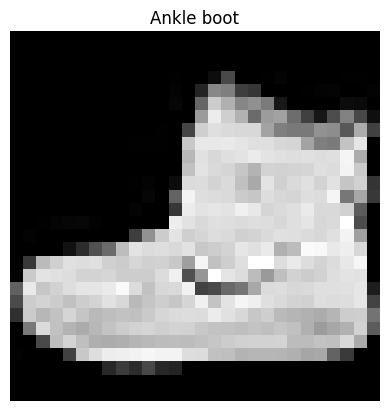

In [33]:
#visualizing the image graphically with the label
plt.imshow(image.squeeze(), cmap="gray")
plt.title(train_data.classes[label])
plt.axis("off")
plt.show()

In [34]:
#checking the classes of the dataset in train_data
classes = train_data.classes
classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

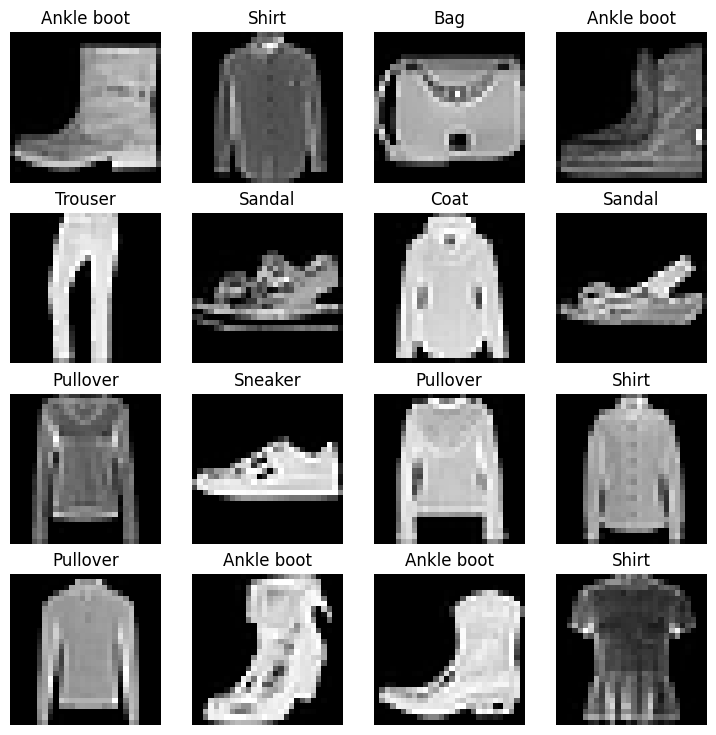

In [35]:
#visualizing random images from train_data
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(classes[label])
    plt.axis(False);

In [36]:
#created batches of the train and test dataset
torch.manual_seed(42)
BATCH_SIZE = 32

train_DataLoader = DataLoader(dataset= train_data,
                              batch_size= BATCH_SIZE,
                              shuffle= True,
                              )

test_DataLoader = DataLoader(dataset= test_data,
                             batch_size= BATCH_SIZE,
                             shuffle= False)

In [37]:
#checking the number of samples
len(train_DataLoader), len(test_DataLoader)

(1875, 313)

In [38]:
#checking the shape of 1 sample out of the 1875 samples of train_DataLoader where 32 represents the total images a single sample contains
single_sample_images , single_sample_labels = next(iter(train_DataLoader))
single_sample_images.shape, single_sample_labels.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

In [39]:
#visualizing the sample and label (32 images in a singel sample = 32 tensors representing the pixel values of 32 iamges and 32 labels for 32 images)
single_sample_images, single_sample_labels

(tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],
 
 
         [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],
 
 
         [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000

Image size: torch.Size([1, 28, 28])
Label: 9, label size: torch.Size([])


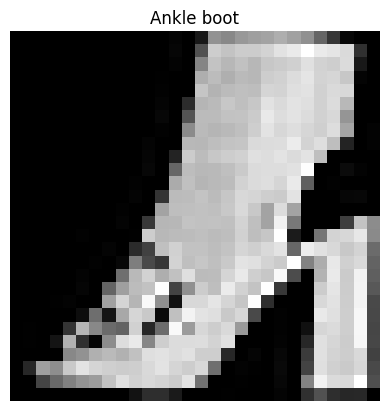

In [40]:
#visualizing 1 image out of the 32 images from the 1 sample i.e (single_sample_image) which we took out of the 1875 samples i.e (train_DataLoader)
torch.manual_seed(42)
random_idx = torch.randint(0, len(single_sample_images), size=[1]).item()
img, label = single_sample_images[random_idx], single_sample_labels[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(classes[label])
plt.axis("Off");
print(f"Image size: {img.shape}")
print(f"Label: {label}, label size: {label.shape}")

In [41]:
class FashionMNISTModel(nn.Module):
  def __init__(self, input_shape, hidden_units, output_shape):
    super().__init__()

    self.block1 = nn.Sequential(
        nn.Conv2d(in_channels= input_shape,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride= 1,
                  padding= 1),
        nn.ReLU(),
        nn.Conv2d(in_channels= hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride= 1,
                  padding= 1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size= 2)
        )

    self.block2 = nn.Sequential(
        nn.Conv2d(in_channels= hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride= 1,
                  padding= 1),
        nn.ReLU(),
        nn.Conv2d(in_channels= hidden_units,
                  out_channels = hidden_units,
                  kernel_size= 3,
                  stride= 1,
                  padding= 1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size= 2)
        )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features= hidden_units*7*7,
                  out_features= output_shape)
        )

  def forward(self, x):
    x = self.block1(x)
    #print(x.shape)
    x = self.block2(x)
    #print(x.shape)
    x = self.classifier(x)
    #print(x.shape)
    return x

torch.manual_seed(42)
model = FashionMNISTModel(input_shape= 1,
                             hidden_units = 10,
                             output_shape = len(classes)).to(device)
model

FashionMNISTModel(
  (block1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [42]:
single_sample_images.shape

torch.Size([32, 1, 28, 28])

In [43]:
#created a random sample data to check the dimensions for
random_sample_data = torch.randn(1,1,28,28)

In [44]:
model(random_sample_data.to(device))

tensor([[ 0.0366, -0.0940,  0.0686, -0.0485,  0.0068,  0.0290,  0.0132,  0.0084,
         -0.0030, -0.0185]], grad_fn=<AddmmBackward0>)

In [45]:
len(test_DataLoader)

313

In [46]:
acc = Accuracy(task= 'multiclass', num_classes= 10).to(device)

In [47]:
#testing the accuracy of the untrained model
model.eval()
with torch.inference_mode():

  untrained_accuracy = 0

  for test_img, test_labels in test_DataLoader:
    test_img, test_labels = test_img.to(device), test_labels.to(device)
    test_preds = model(test_img)

    untrained_accuracy += acc(test_preds.argmax(dim=1), test_labels)

  untrained_accuracy /= len(test_DataLoader)
  acc.reset()

  print(f"{untrained_accuracy*100:.2f}")

9.99


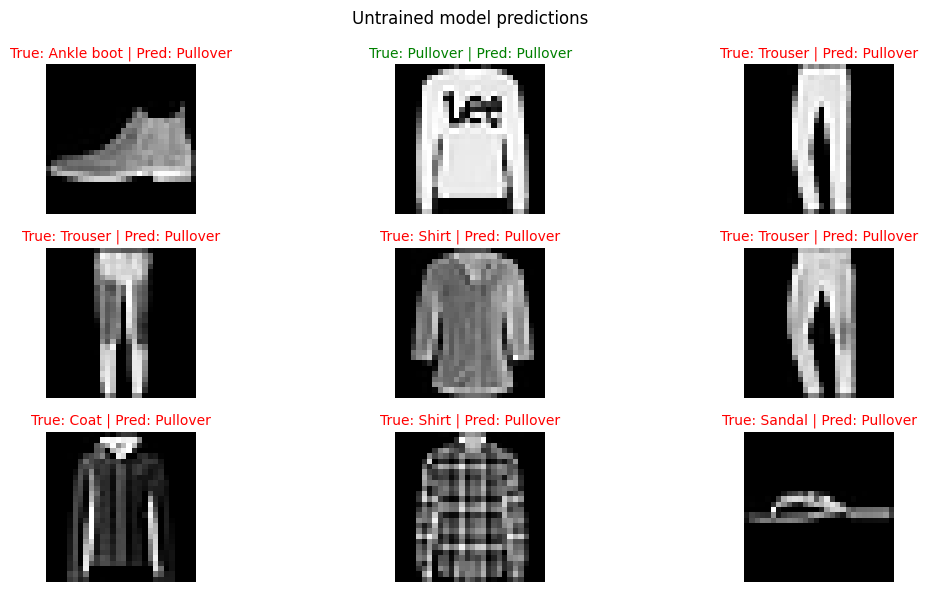

In [48]:
fig, axes = plt.subplots(3, 3, figsize=(12, 6))
fig.suptitle("Untrained model predictions")

model.eval()
with torch.inference_mode():
    for i, ax in enumerate(axes.flat):
        image, label = test_data[i]
        pred = model(image.unsqueeze(0).to(device))
        pred_label = pred.argmax(dim=1).item()

        ax.imshow(image.squeeze(), cmap="gray")
        ax.set_title(
    f"True: {test_data.classes[label]} | Pred: {test_data.classes[pred_label]}",
    fontsize=10,
    color="green" if pred_label == label else "red"
)
        ax.axis("off")

plt.tight_layout()
plt.show()

In [49]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
acc = Accuracy(task= 'multiclass', num_classes= 10).to(device)

In [50]:
torch.manual_seed(42)

epochs = 5
train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

for epoch in range(epochs):
  print(f"Epoch: {epoch}\n")
  train_loss, train_accuracy = 0, 0
  model.train()

  for batch, (train_img_X, train_labels_y) in enumerate(train_DataLoader):
    train_img_X, train_labels_y = train_img_X.to(device), train_labels_y.to(device)

    train_logits = model(train_img_X)

    loss = loss_fn(train_logits, train_labels_y)
    train_loss += loss
    train_accuracy += acc(train_logits.argmax(dim = 1), train_labels_y)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if batch % 400 == 0:
      print(f"Looked at {batch * len(train_img_X)}/{len(train_DataLoader.dataset)} samples")

  train_loss /= len(train_DataLoader)
  train_accuracy /= len(train_DataLoader)
  acc.reset()


  test_loss, test_accuracy = 0, 0
  model.eval()
  with torch.inference_mode():

    for test_img_X, test_labels_y in test_DataLoader:
      test_img_X, test_labels_y = test_img_X.to(device), test_labels_y.to(device)

      test_logits = model(test_img_X)

      test_loss+= loss_fn(test_logits, test_labels_y)
      test_accuracy+= acc(test_logits.argmax(dim= 1), test_labels_y)

    test_loss /= len(test_DataLoader)
    test_accuracy /= len(test_DataLoader)
    acc.reset()

  train_losses.append(train_loss.item())
  test_losses.append(test_loss.item())
  train_accuracies.append(train_accuracy.item())
  test_accuracies.append(test_accuracy.item())


  print(f"Train_loss: {train_loss:.3f} | Train_accuracy: {train_accuracy:.3f} | Test_loss: {test_loss:.3f} | Test_accuracy: {test_accuracy:.3f}")


Epoch: 0

Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train_loss: 0.537 | Train_accuracy: 0.804 | Test_loss: 0.404 | Test_accuracy: 0.855
Epoch: 1

Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train_loss: 0.366 | Train_accuracy: 0.868 | Test_loss: 0.378 | Test_accuracy: 0.864
Epoch: 2

Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train_loss: 0.331 | Train_accuracy: 0.881 | Test_loss: 0.339 | Test_accuracy: 0.878
Epoch: 3

Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train_loss: 0.309 | Train_accuracy: 0.889 | Test_loss: 0.327 | Test_accuracy: 0.885
Epoch: 4

Looked at 0/60000 samples
Look

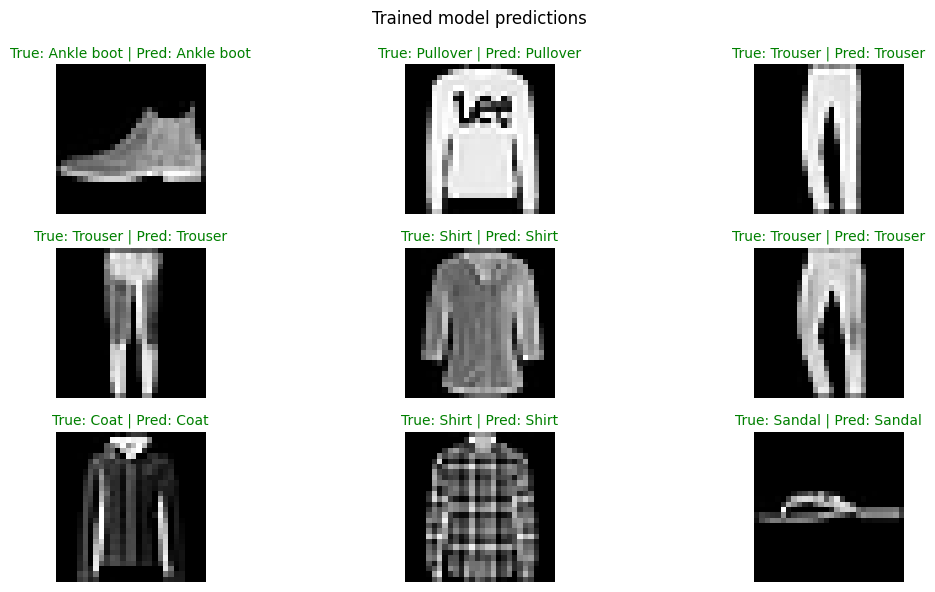

In [51]:
fig, axes = plt.subplots(3, 3, figsize=(12, 6))
fig.suptitle("Trained model predictions")

model.eval()
with torch.inference_mode():
    for i, ax in enumerate(axes.flat):
        image, label = test_data[i]
        pred = model(image.unsqueeze(0).to(device))
        pred_label = pred.argmax(dim=1).item()

        ax.imshow(image.squeeze(), cmap="gray")
        ax.set_title(
    f"True: {test_data.classes[label]} | Pred: {test_data.classes[pred_label]}",
    fontsize=10,
    color="green" if pred_label == label else "red"
)
        ax.axis("off")



plt.tight_layout()
plt.show()

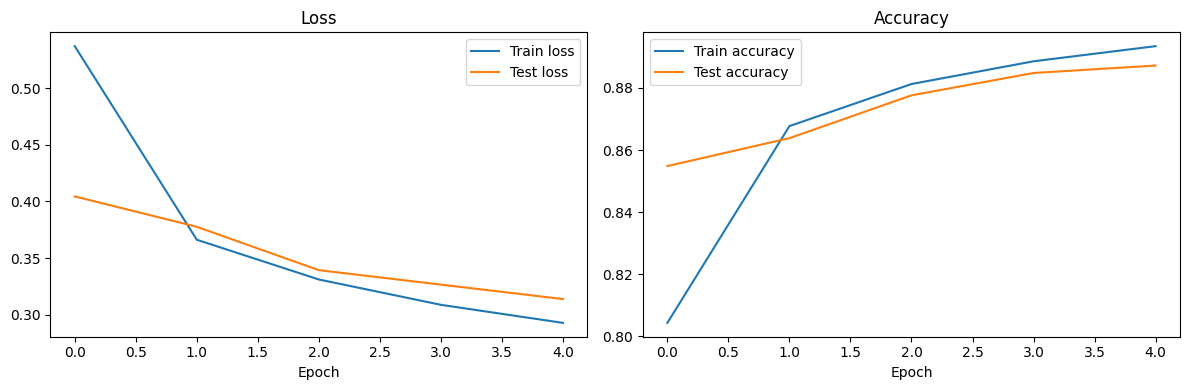

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
axes[0].plot(train_losses, label="Train loss")
axes[0].plot(test_losses, label="Test loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

# Accuracy plot
axes[1].plot(train_accuracies, label="Train accuracy")
axes[1].plot(test_accuracies, label="Test accuracy")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

In [53]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True,
                 exist_ok=True
)

MODEL_NAME = "FashionMNISTModel.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model.state_dict(),
           f=MODEL_SAVE_PATH)

Saving model to: models/FashionMNISTModel.pth


In [55]:
loaded_model = FashionMNISTModel(input_shape=1,
                                 hidden_units=10,
                                 output_shape=10)

loaded_model.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

loaded_model = loaded_model.to(device)

In [57]:
loaded_model.eval()
with torch.inference_mode():

  loaded_model_accuracy = 0

  for img, labels in test_DataLoader:
    img, labels = img.to(device), labels.to(device)
    preds = loaded_model(img)
    loaded_model_accuracy += acc(preds.argmax(dim=1), labels)

  loaded_model_accuracy /= len(test_DataLoader)
  acc.reset()
  print(f"{loaded_model_accuracy*100:.2f}")

88.72
